In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

stats_dir = Path('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe')
box_stats_dir = Path('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/box/')

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh2_correlation_raw_LRG_z0.4-0.6_NGC_weight-default-FKP_0.h5


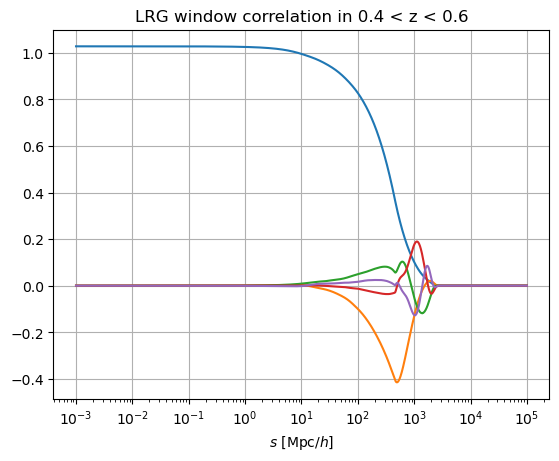

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh3_correlation_raw_LRG_z0.4-0.6_NGC_weight-default-FKP_0.h5


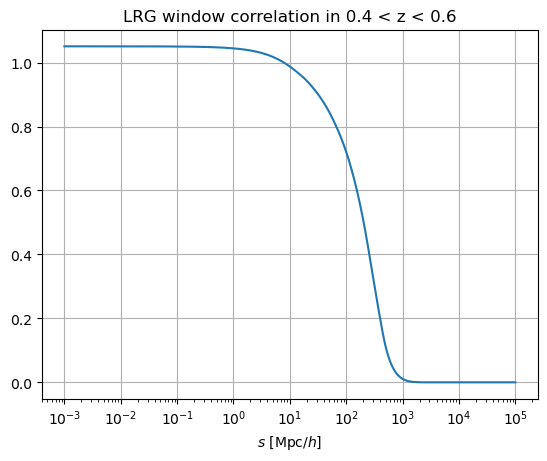

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh2_correlation_raw_LRG_z0.6-0.8_NGC_weight-default-FKP_0.h5


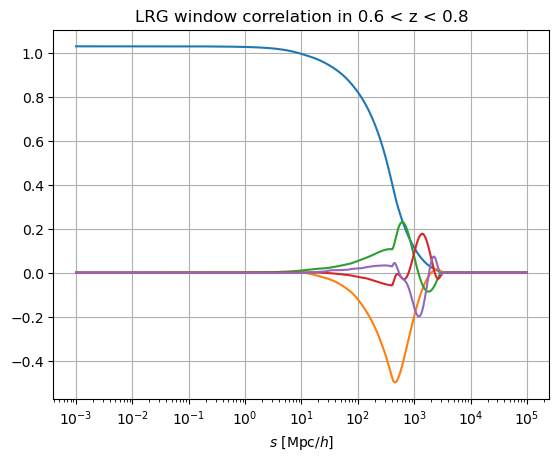

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh3_correlation_raw_LRG_z0.6-0.8_NGC_weight-default-FKP_0.h5


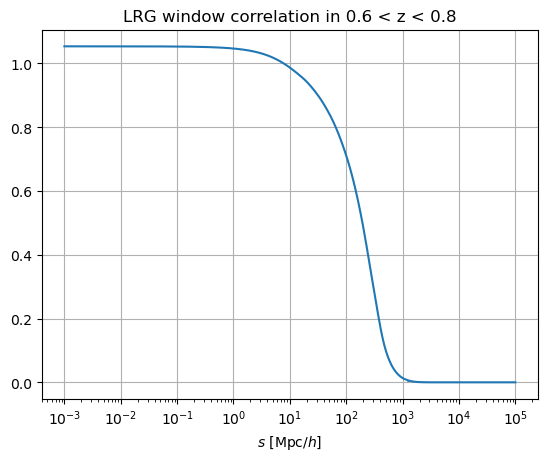

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh2_correlation_raw_LRG_z0.8-1.1_NGC_weight-default-FKP_0.h5


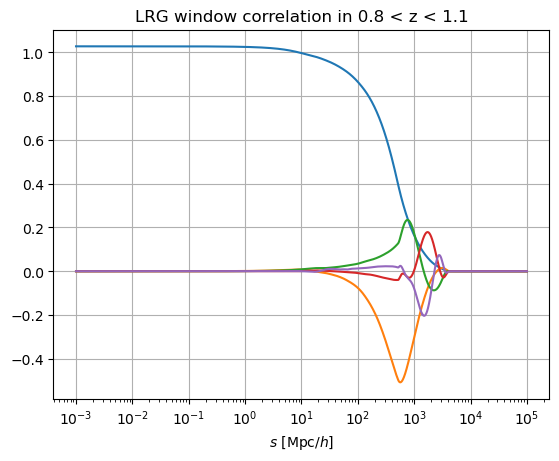

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh3_correlation_raw_LRG_z0.8-1.1_NGC_weight-default-FKP_0.h5


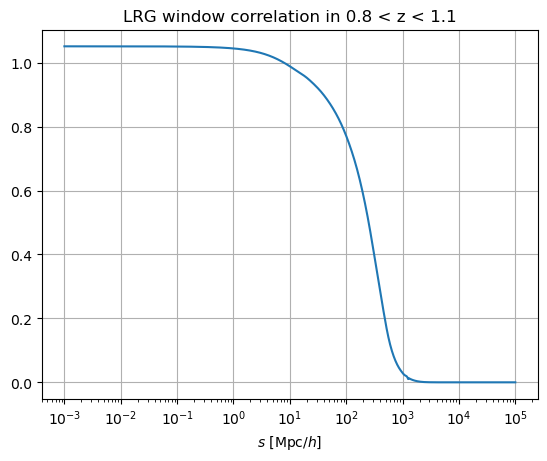

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh2_correlation_raw_ELG_LOP_z0.8-1.1_NGC_weight-default-FKP_0.h5


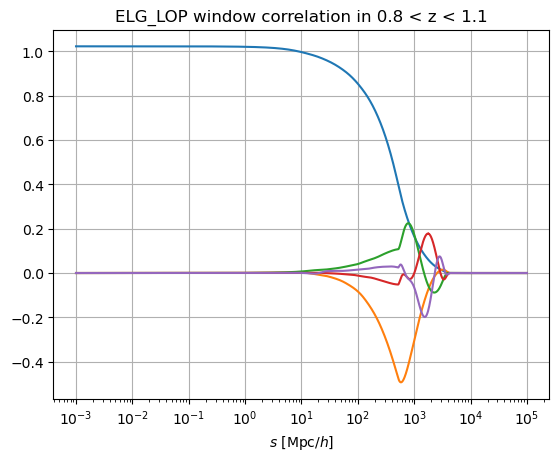

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh3_correlation_raw_ELG_LOP_z0.8-1.1_NGC_weight-default-FKP_0.h5


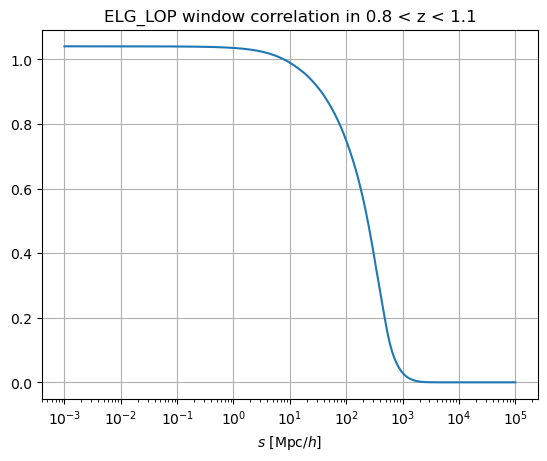

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh2_correlation_raw_ELG_LOP_z1.1-1.6_NGC_weight-default-FKP_0.h5


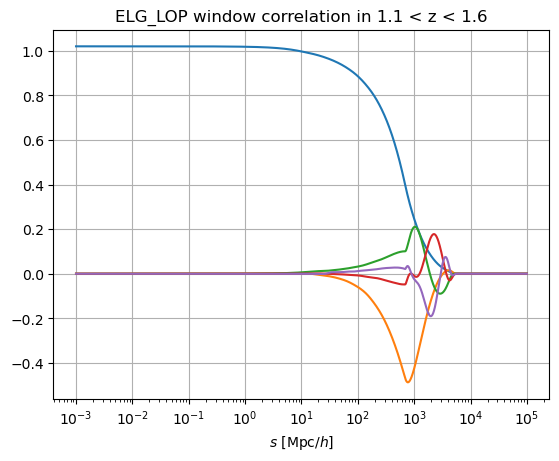

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh3_correlation_raw_ELG_LOP_z1.1-1.6_NGC_weight-default-FKP_0.h5


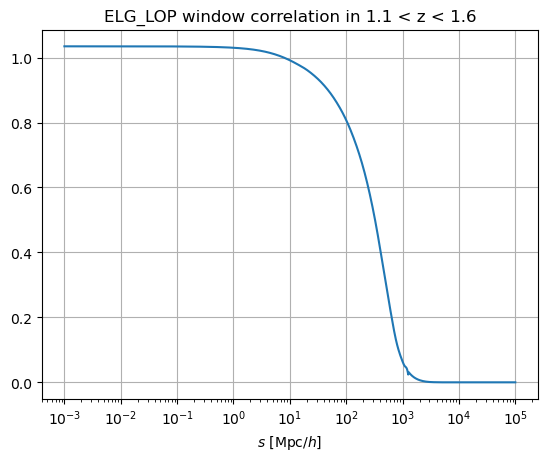

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh2_correlation_raw_QSO_z0.8-2.1_NGC_weight-default-FKP_0.h5


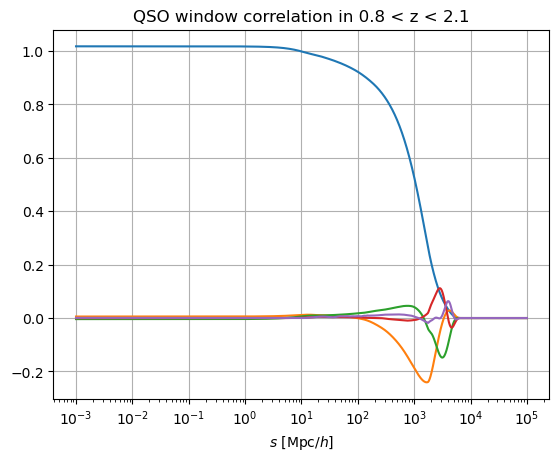

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/window_mesh3_correlation_raw_QSO_z0.8-2.1_NGC_weight-default-FKP_0.h5


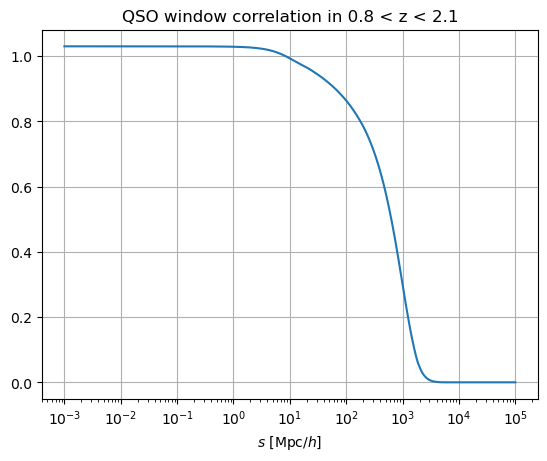

In [2]:
for tracer in ['LRG', 'ELG_LOP', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum', 'mesh3_spectrum']:
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=f'window_{kind.replace("_spectrum", "")}_correlation_raw', version='abacus-2ndgen-complete', tracer=tracer,
                                    zrange=zrange, region='NGC', weight='default-FKP', basis='sugiyama-diagonal', imock=0)
            print(fn)
            window_correlation = types.read(fn)
            fig, ax = plt.subplots()
            ax.set_title(f'{tracer} window correlation in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            for ill, (label, pole) in enumerate(window_correlation.items(level=None)):
                color = f'C{ill:d}'
                if pole.ndim > 1:
                    slim = (1e3, 2e3)
                    #pole = pole.select(s1=slim, s2=slim)
                    ax.plot(s:=pole.coords('s1'), pole.value().diagonal(), color=color)
                else:
                    #pole = pole.select(s=(1e3, 1e4))
                    ax.plot(s:=pole.coords('s'), pole.value(), color=color)
            ax.set_xscale('log')
            ax.set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
            ax.grid(True)
            plt.show()

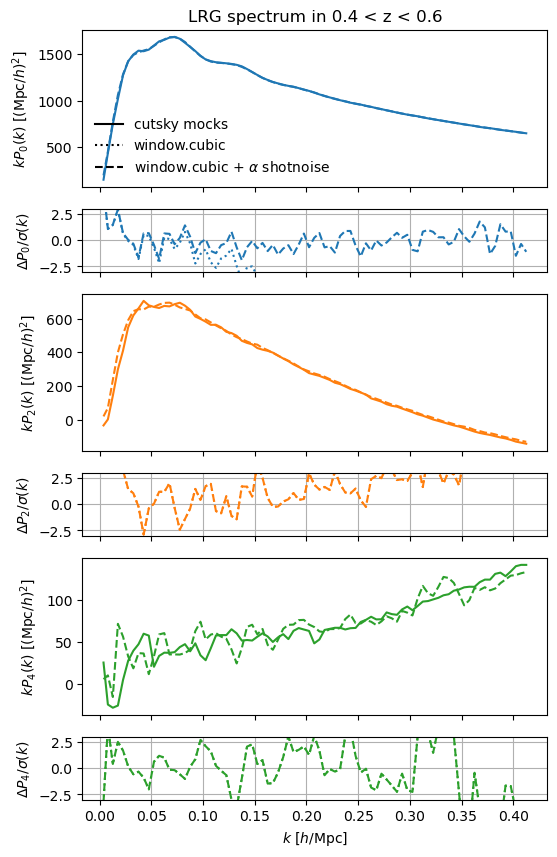

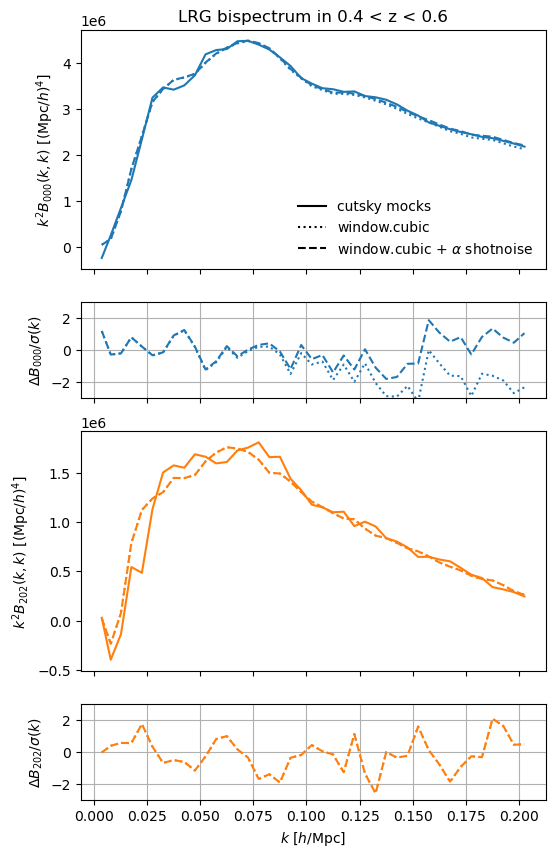

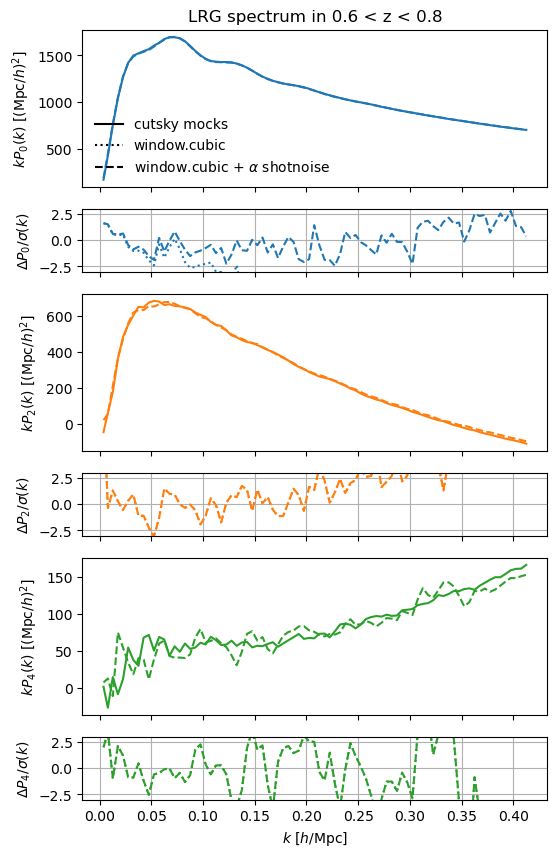

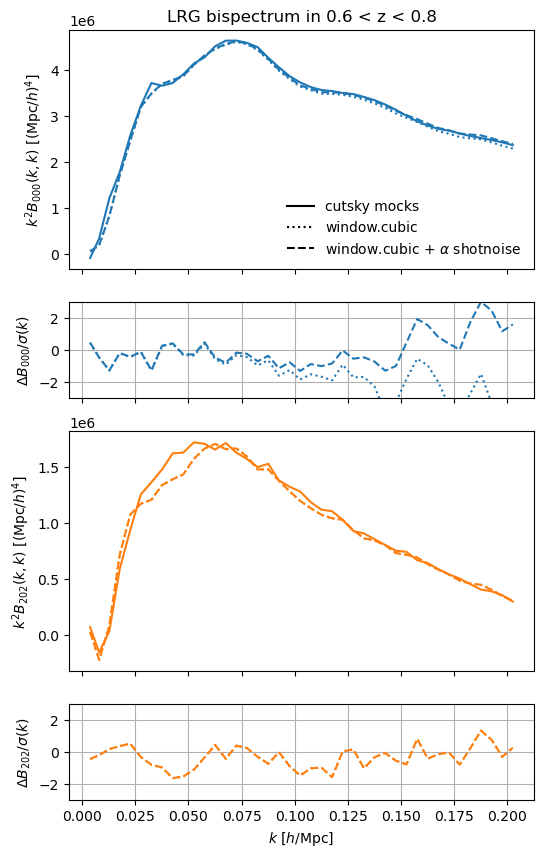

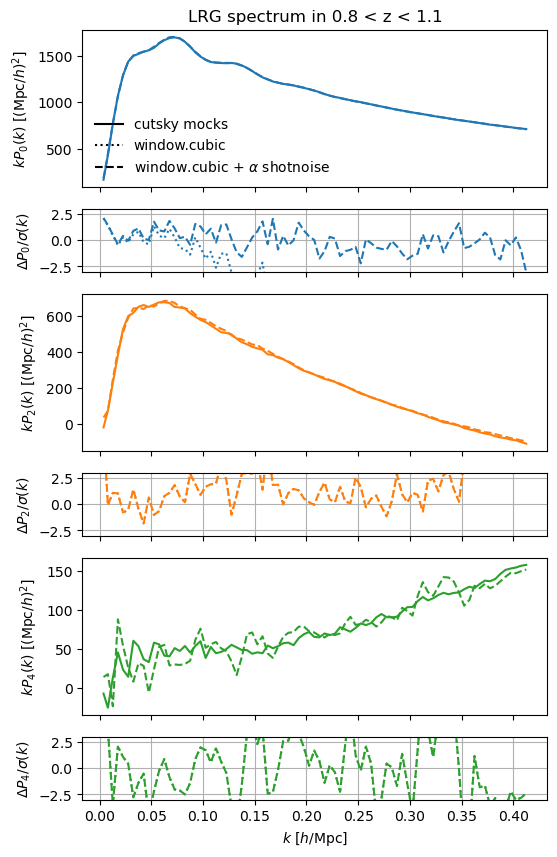

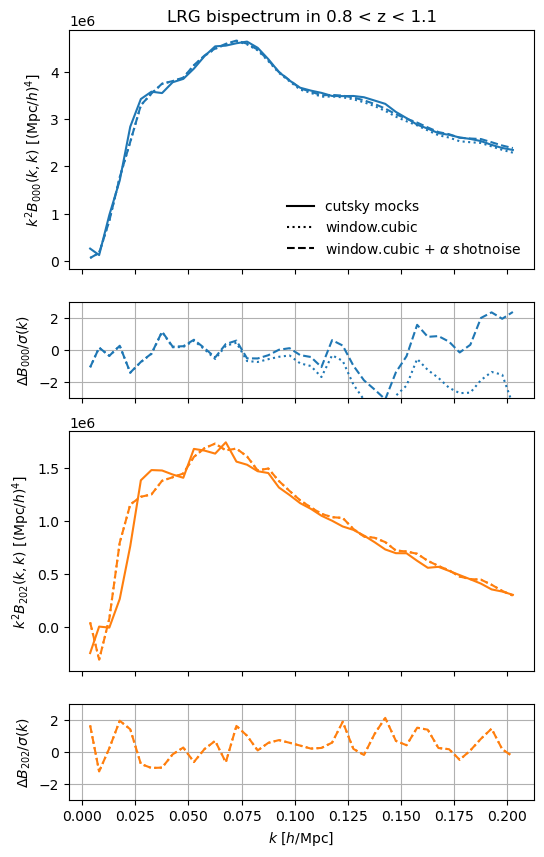

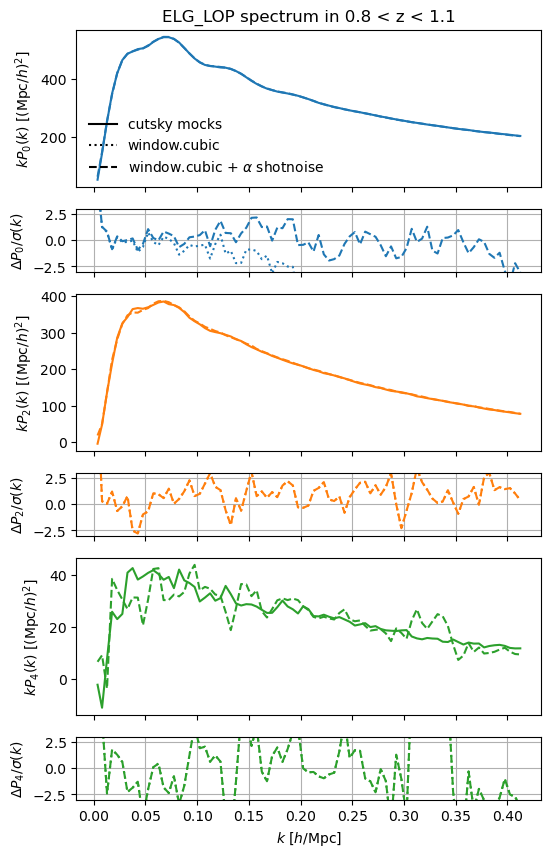

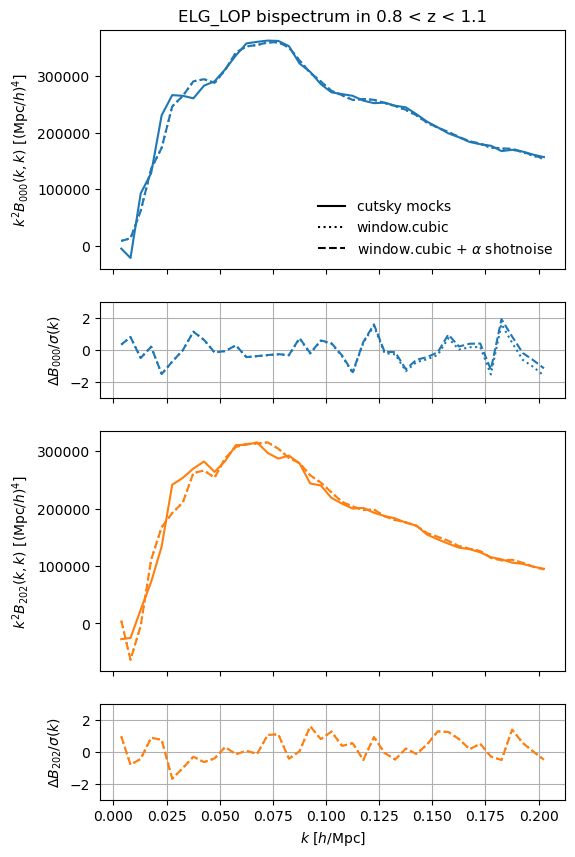

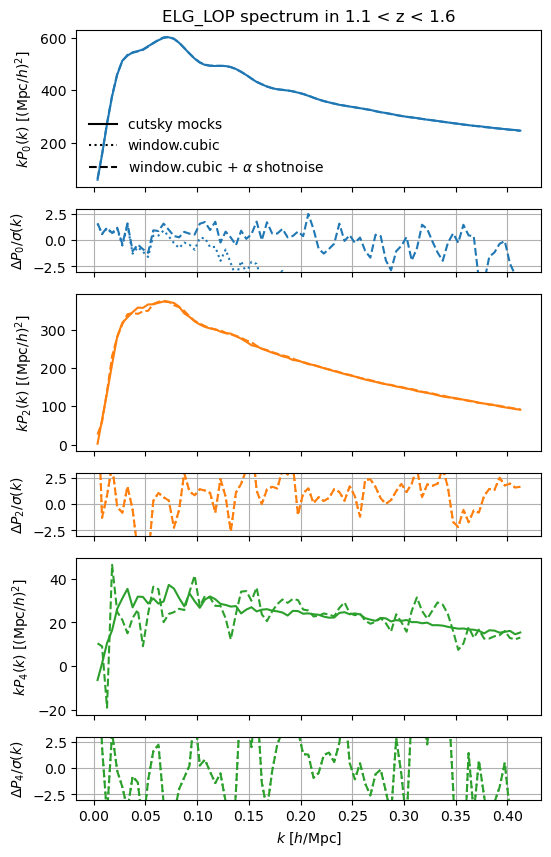

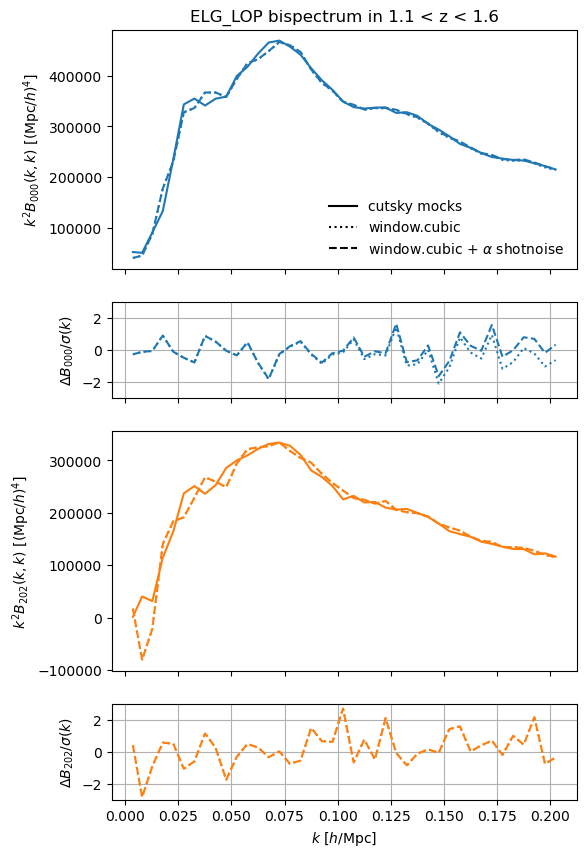

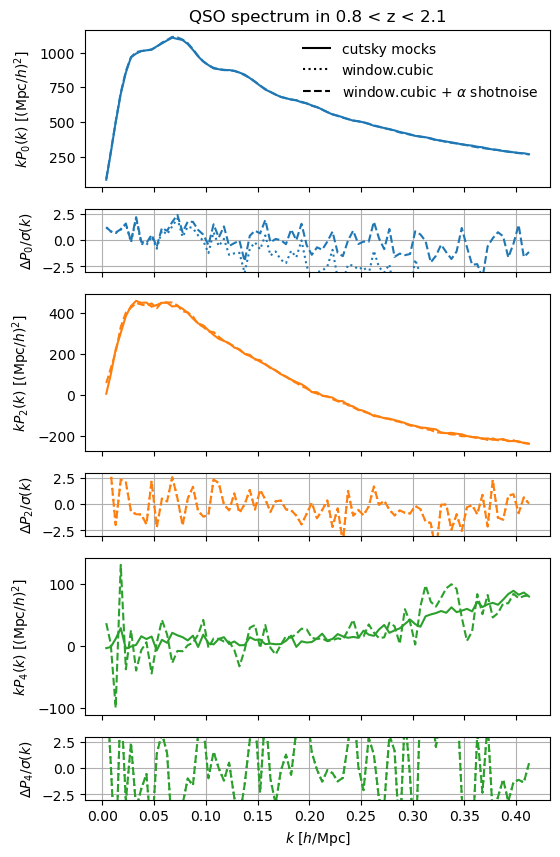

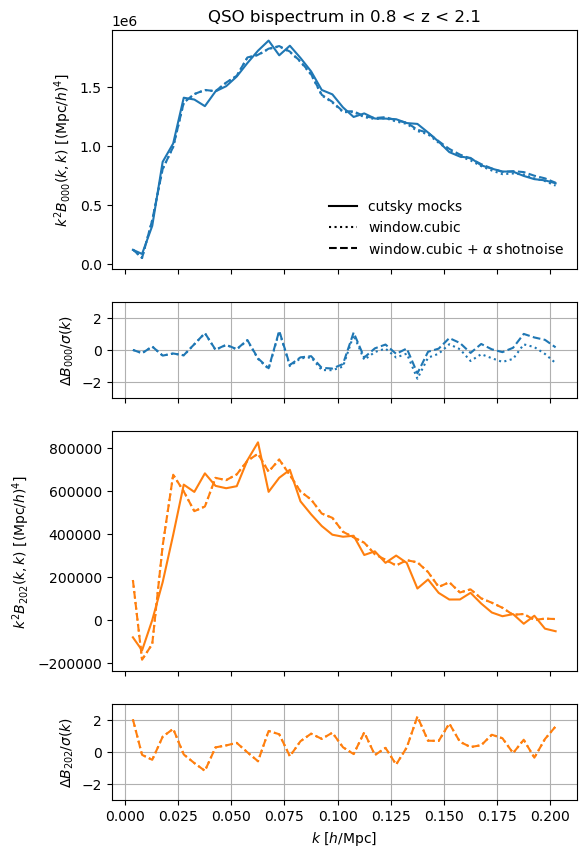

In [3]:
for tracer in ['LRG', 'ELG_LOP', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        for kind in ['mesh2_spectrum', 'mesh3_spectrum']:
            nmocks = 25
            zsnap = box_tools.get_zsnap_from_z(tracer, zrange, version='abacus-2ndgen')
            fns = [box_tools.get_box_stats_fn(stats_dir=box_stats_dir, kind=kind, version='abacus-2ndgen', tracer=tools.get_simple_tracer(tracer),
                                              zsnap=zsnap, region='GCcomb', weight='default-FKP', cosmo='000', hod=None, los='z', basis='sugiyama', imock=imock) for imock in range(nmocks)]
            mocks_box = [types.read(fn) for fn in fns if fn.exists()]
            mean_box = types.mean(mocks_box)
            fns = [tools.get_stats_fn(stats_dir=stats_dir, kind=kind, version='abacus-2ndgen-complete', tracer=tracer,
                                      zrange=zrange, region='GCcomb', weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(nmocks)]
            mocks_cutsky = [types.read(fn) for fn in fns if fn.exists()]
            cov_cutsky = types.cov(mocks_cutsky)
            cov_cutsky = cov_cutsky.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
            mean_cutsky = cov_cutsky.observable
            fn = tools.get_stats_fn(stats_dir=stats_dir, kind=f'window_{kind}', version='abacus-2ndgen-complete', tracer=tracer,
                                    zrange=zrange, region='GCcomb', weight='default-FKP', basis='sugiyama-diagonal', imock=0)
            window_cutsky = types.read(fn).at.observable.match(mean_cutsky)
            mean_box_interp = []
            for label, pole in window_cutsky.theory.items():
                pole_box = mean_box.get(ells=label['ells'])
                if 'mesh3' in kind:
                    pole_box = pole_box.unravel()
                    from scipy import interpolate
                    mask1, mask2 = [np.any(pole_box.values('nmodes') > 0, axis=axis) for axis in [1, 0]]
                    spline = interpolate.RectBivariateSpline(pole_box.coords('k1')[mask1], pole_box.coords('k2')[mask2], pole_box.value()[np.ix_(mask1, mask2)], kx=1, ky=1, s=0)
                    pole = spline(*pole.coords('k').T, grid=False)
                else:
                    mask = pole_box.values('nmodes') > 0
                    pole = np.interp(pole.coords('k'), pole_box.coords('k')[mask], pole_box.value()[mask])
                mean_box_interp.append(pole)
            mean_box_interp = window_cutsky.theory.clone(value=np.concatenate(mean_box_interp))
            mean_box_conv = window_cutsky.dot(mean_box_interp, return_type=None)
            
            shotnoise = window_cutsky.theory.clone(value=0. * window_cutsky.theory.value()).value(concatenate=False)
            shotnoise[0] += next(iter(mean_cutsky)).values('shotnoise').mean()
            shotnoise = window_cutsky.dot(np.concatenate(shotnoise), return_type='nparray')[None, ...]
            precision = np.diag(1. / cov_cutsky.std())
            # Solve d\chi^2 / drescale = 0, theory = rescale * shotnoise, data = mean_cutsky - mean_box_conv
            rescale = np.linalg.solve(shotnoise.dot(precision).dot(shotnoise.T), shotnoise.dot(precision).dot(mean_cutsky.value() - mean_box_conv.value()))
            mean_box_conv_shotnoise = mean_box_conv.clone(value=mean_box_conv.value() + rescale.dot(shotnoise))

            nmocks = min(len(mocks_box), len(mocks_cutsky))  # scale error bars
            if 'mesh2' in kind:
                ells = mean_cutsky.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(mean_cutsky.ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
                    color = f'C{ill:d}'
                    #pole = mean_box.get(ell).select(k=slice(0, None, 5)).select(k=(0., mean_cutsky.get(ell).edges('k').max()))
                    #ax.plot(pole.coords('k'), pole.coords('k') * pole.value(), color=color, linestyle=':')
                    pole = mean_cutsky.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
                    pole = mean_box_conv.get(ell)
                    #ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-3., 3.)
                    pole_cutsky = mean_cutsky.get(ell)
                    std = cov_cutsky.at.observable.get(ell).std() / nmocks**0.5
                    pole = mean_box_conv.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_cutsky.value()) / std, color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(pole.coords('k'), (pole.value() - pole_cutsky.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='cutsky mocks')
                ax.plot([], [], color='k', linestyle=':', label='window.cubic')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)
                plt.show()

            elif 'mesh3' in kind:
                ells = mean_cutsky.ells
                fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
                lax[0].set_title(f'{tracer} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
                for ill, ell in enumerate(ells):
                    ax = lax[2 * ill]
                    ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
                    color = f'C{ill:d}'
                    #pole = mean_box.get(tuple(sorted(ell[:2])) + ell[2:]).unravel()
                    #ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, linestyle=':')
                    #pole = mean_box_interp.get(ells=tuple(sorted(ell[:2])) + ell[2:]).unravel()
                    #ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, linestyle='-')
                    pole = mean_cutsky.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='-')
                    pole = mean_box_conv.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color=color, linestyle='--')
                    ax = lax[2 * ill + 1]
                    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
                    ax.grid(True)
                    ax.set_ylim(-3., 3.)
                    pole_cutsky = mean_cutsky.get(ell)
                    std = cov_cutsky.at.observable.get(ell).std() / nmocks**0.5
                    pole = mean_box_conv.get(ell)
                    ax.plot(k, (pole.value() - pole_cutsky.value()) / std, color=color, linestyle=':')
                    pole = mean_box_conv_shotnoise.get(ell)
                    ax.plot(k, (pole.value() - pole_cutsky.value()) / std, color=color, linestyle='--')
                ax = lax[0]
                ax.plot([], [], color='k', linestyle='-', label='cutsky mocks')
                ax.plot([], [], color='k', linestyle=':', label='window.cubic')
                ax.plot([], [], color='k', linestyle='--', label=r'window.cubic + $\alpha$ shotnoise')
                lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
                ax.legend(frameon=False)
                plt.show()

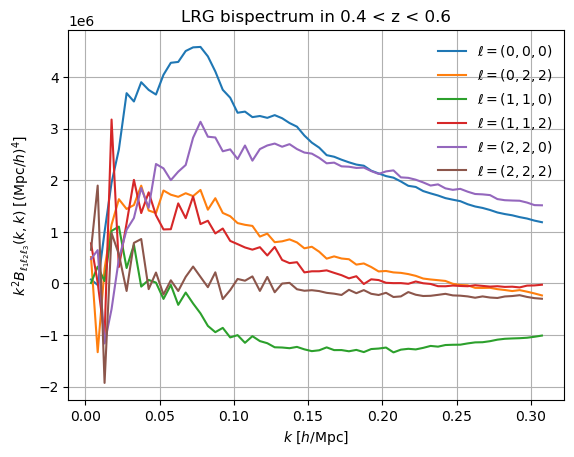

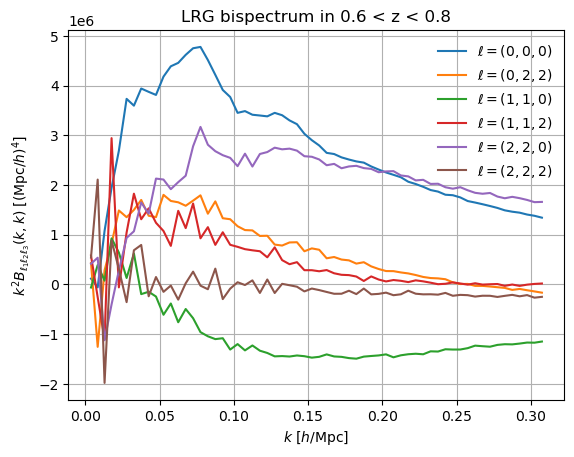

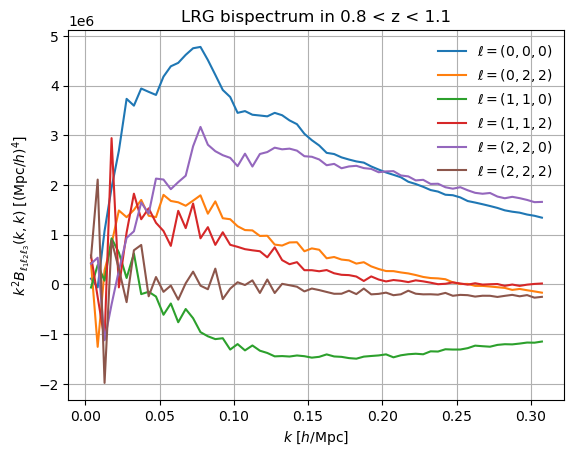

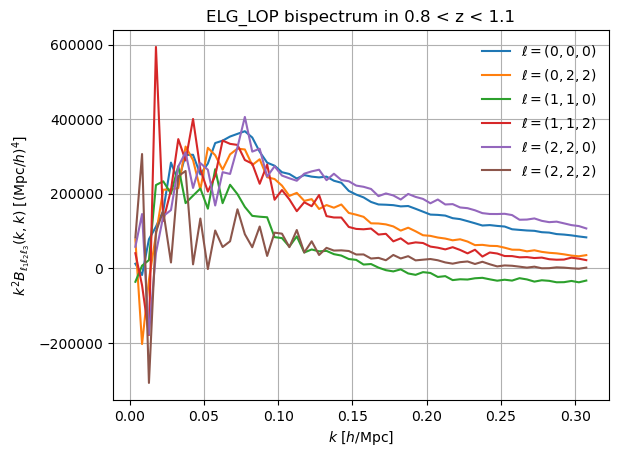

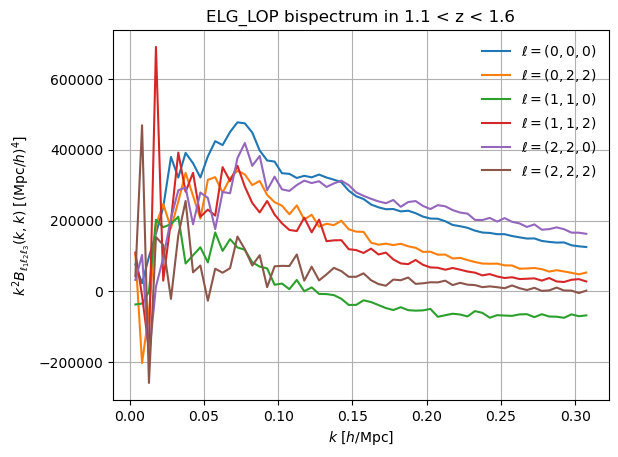

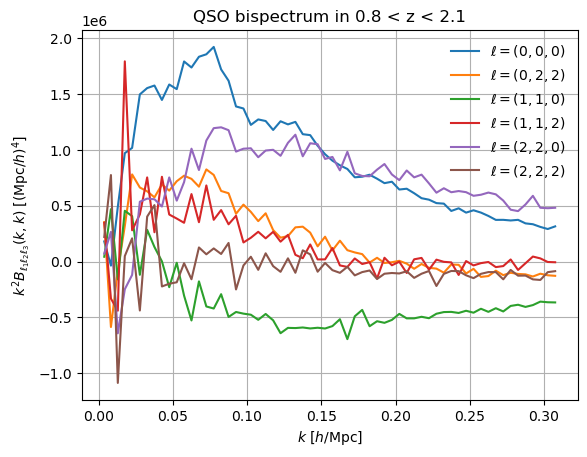

In [4]:
for tracer in ['LRG', 'ELG_LOP', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        zsnap = box_tools.get_zsnap_from_z(tracer, zrange, version='abacus-2ndgen')
        for kind in ['mesh3_spectrum']:
            nmocks = 25
            fns = [box_tools.get_box_stats_fn(stats_dir=box_stats_dir, kind=kind, version='abacus-2ndgen', tracer=tools.get_simple_tracer(tracer),
                                              zsnap=zsnap, region='GCcomb', weight='default-FKP', cosmo='000', hod=None, los='z', basis='sugiyama', imock=imock) for imock in range(nmocks)]
            mocks_box = [types.read(fn) for fn in fns if fn.exists()]
            mean_box = types.mean(mocks_box)
            fig, ax = plt.subplots()
            ax.set_title(f'{tracer} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            for ill, ell in enumerate(mean_box.ells):
                color = f'C{ill:d}'
                pole = mean_box.get(ell).unravel()
                ax.plot(k:=pole.coords('k1'), k**2 * np.diag(pole.value()), color=color, label=rf'$\ell={ell}$')
            ax.set_ylabel(r'$k^2 B_{\ell_1\ell_2\ell_3}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
            ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
            ax.grid(True)
            ax.legend(frameon=False)
            plt.show()  